# Time series prediction using LSTM

## Dataset
- Daily minimum temperatures in Melbourne, Australia, 1981-1990
- Units: Degrees Celcius

## Question 1

### Load the data
- load daily-minimum-temperatures-in-me.csv

In [1]:
import tensorflow as tf
import pandas as pd
import csv
import numpy as np
from PIL import Image
import math
from sklearn.metrics import mean_squared_error
import matplotlib.pyplot as plt

from keras import Model
from keras.callbacks import ModelCheckpoint, EarlyStopping, Callback
from tensorflow.keras.utils import Sequence
from keras.models import Sequential
from keras.layers import LSTM
from keras.layers import Dense

Using TensorFlow backend.


### Print the data
- First 5 rows only

### Set index column
- Set the DataFrame index using "Date" column

In [2]:
df = pd.read_csv('daily-minimum-temperatures-in-me.csv',index_col='Date')

In [3]:
print(df.head())

            Temperature
Date                   
1981-01-01         20.7
1981-01-02         17.9
1981-01-03         18.8
1981-01-04         14.6
1981-01-05         15.8


## Question 2

### Check the total count of null values in the data

In [4]:
print(df.isnull().any(axis=1).sum())

0


### Drop all the rows with null values
- use dropna() method

In [5]:
df.dropna(inplace=True)
df.isnull().sum()

Temperature    0
dtype: int64

## Question 3

### Describe your dataframe
- use describe() method

In [6]:
df.describe()

,Temperature
count,3650.000000
mean,11.177753
std,4.071837
min,0.000000
25%,8.300000
50%,11.000000
75%,14.000000
max,26.300000


### Plot the dataframe
- use plot() method

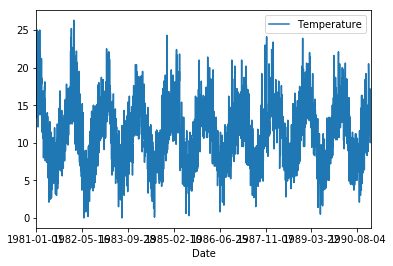

In [7]:
df.plot()

### Get representation of the distribution of data using histogram
- use hist() method

array([[<matplotlib.axes._subplots.AxesSubplot object at 0x7fec740ffb70>]],
      dtype=object)

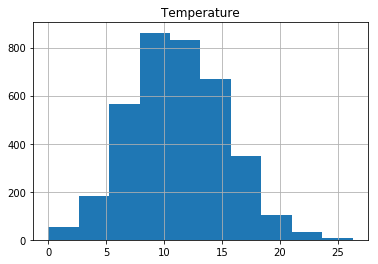

In [8]:
df.hist()

### Check minimum and maximum temperature
- use min() and max() methods

In [9]:
print('Min', np.min(df))

Min Temperature    0.0
dtype: float64


In [10]:
print('Max', np.max(df))

Max Temperature    26.3
dtype: float64


## Question 4

### Split the dataset into training and testing
- training data: 75%
- testing data: 25%

In [11]:
dataset = df.astype('float32')

### Normalize the data
- normalize temperature values using MinMaxScaler
- feature_range: 0-1
- fit MinMaxScaler on train data and transform it
  - use fit_transform() method
- transform test data using MinMaxScaler object
  - use transform() method

In [12]:
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler(feature_range=(0, 1))
scaled = scaler.fit_transform(dataset)

/home/siju/.local/lib/python3.6/site-packages/sklearn/preprocessing/data.py:323: DataConversionWarning: Data with input dtype float32 were all converted to float64 by MinMaxScaler.
  return self.partial_fit(X, y)


In [13]:
print('Min', np.min(scaled))

Min 0.0


In [14]:
print('Max', np.max(scaled))

Max 1.0


In [15]:
train_size = int(len(scaled) * 0.75)
test_size = len(scaled - train_size)
train, test = scaled[0:train_size, :], scaled[train_size: len(scaled), :]

### Print scaled train and test data
- print only first 5 values

In [16]:
print('train: {}\ntest: {}'.format(len(train), len(test)))

train: 2737
test: 913


In [17]:
print("First 5 train rows = ", train[0:5])

First 5 train rows =  [[0.7870723 ]
 [0.68060837]
 [0.71482889]
 [0.55513311]
 [0.60076048]]


In [18]:
print("First 5 test rows = ", test[0:5])

First 5 test rows =  [[0.22813689]
 [0.22053233]
 [0.1863118 ]
 [0.19011407]
 [0.31939163]]


## Question 5

### Create sequential data
Map the temperature at a particular day 'd' to the temperature at day t
'd+n', where n is any number you define.

For example: to map temperatures of consecutive days, use d+1, i.e. lookback = 1
- Below function takes data as input and returns sequential data.
- X as features and y as labels

In [19]:
def create_dataset(dataset, look_back=1):
    print(len(dataset), look_back)
    dataX, dataY = [], []
    for i in range(len(dataset)-look_back-1):
        a = dataset[i:(i+look_back), 0]
        dataset[i + look_back, 0]
        dataX.append(a)
        dataY.append(dataset[i + look_back, 0])
    return np.array(dataX), np.array(dataY)

### Use the above function to create train and test sets
- Get X_train and y_train
- Get X_test and y_test
- lookback = 1

In [20]:
look_back = 1
X_train, y_train = create_dataset(train, look_back)
X_test, y_test = create_dataset(test, look_back)

2737 1
913 1


### Reshape the data
- Reshape X_train and X_test
- use np.reshape() method
- this is to be done to make the data ready for input in model

In [21]:
X_train = np.reshape(X_train, (X_train.shape[0], X_train.shape[1], 1))
X_test = np.reshape(X_test, (X_test.shape[0], X_test.shape[1], 1))

### Print shape of data
- print shape of X_train and X_test

In [22]:
print(X_train.shape)
print(X_test.shape)

(2735, 1, 1)
(911, 1, 1)


## Question 6

### Define sequential model
- initialize a Sequential model
- add an LSTM layer
  - units: 10
  - stateful: True
  - pass a `batch_input_shape` argument to your layer
  - batch_input_shape: (batch_size, look_back, 1)
    - batch_size: 1
    - look_back: 1
- add Dense layer with 1 neuron

In [23]:
batch_size = 1
model = Sequential()
model.add(LSTM(10, batch_input_shape=(batch_size, look_back, 1), stateful=True))
model.add(Dense(1))

## Question 7

### compile your model
- loss: mean_squared_error
- optimizer: adam

In [24]:
model.compile(loss='mean_squared_error', optimizer='adam')

### summarize your model
- use summary() method

In [25]:
model.summary()

Model: "sequential_1"
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
lstm_1 (LSTM)                (1, 10)                   480       
_________________________________________________________________
dense_1 (Dense)              (1, 1)                    11        
Total params: 491
Trainable params: 491
Non-trainable params: 0
_________________________________________________________________


## Question 8

### fit your model
- epochs: 50
- batch_size: 1

In [26]:
model.fit(X_train, y_train, epochs=50, batch_size=batch_size, verbose=1, shuffle=True)

Epoch 1/50
2735/2735 [==============================] - 8s 3ms/step - loss: 0.0208
Epoch 2/50
2735/2735 [==============================] - 7s 3ms/step - loss: 0.0102
Epoch 3/50
2735/2735 [==============================] - 7s 3ms/step - loss: 0.0102
Epoch 4/50
2735/2735 [==============================] - 7s 3ms/step - loss: 0.0100
Epoch 5/50
2735/2735 [==============================] - 7s 3ms/step - loss: 0.0101
Epoch 6/50
2735/2735 [==============================] - 7s 3ms/step - loss: 0.0101
Epoch 7/50
2735/2735 [==============================] - 7s 3ms/step - loss: 0.0101
Epoch 8/50
2735/2735 [==============================] - 7s 3ms/step - loss: 0.0100
Epoch 9/50
2735/2735 [==============================] - 7s 3ms/step - loss: 0.0100
Epoch 10/50
2735/2735 [==============================] - 7s 3ms/step - loss: 0.0100
Epoch 11/50
2735/2735 [==============================] - 7s 3ms/step - loss: 0.0100
Epoch 12/50
2735/2735 [==============================] - 7s 3ms/step - loss: 0.0100
E

## Question 9

### make predictions on train data
- use predict() method
  - batch_size: 1
- store predictions in a variable

In [27]:
trainPredict = model.predict(X_train, batch_size=batch_size)

### reset model state
- if you are using stateful=True in your model then you should call reset_states every time, when you want to make consecutive model calls independent.
- use reset_states() method

In [28]:
model.reset_states()

### make predictions on test data
- use predict() method
  - batch_size: 1
- store predictions in a variable

In [29]:
testPredict = model.predict(X_test, batch_size=batch_size)

## Question 10

### Inverse train predictions and true labels
- use your MinMaxSclarer object
- use inverse_transform() method

In [30]:
trainPredict = scaler.inverse_transform(trainPredict)
y_train = scaler.inverse_transform([y_train])

### Inverse test predictions and true labels
- use your MinMaxSclarer object
- use inverse_transform() method

In [31]:
testPredict = scaler.inverse_transform(testPredict)

### Evaluate train predictions
- calculate RMSE
- RMSE = sqrt(mean_squared_error(true_labels, predicted_labels))
- use sqrt() and mean_squared_error() method
- print training RMSE

In [32]:
trainScore = math.sqrt(mean_squared_error(y_train[0], trainPredict[:,0]))

In [33]:
print('Train Score: %.2f RMSE' % (trainScore))

Train Score: 2.58 RMSE


### Evaluate test predictions
- calculate RMSE
- RMSE = sqrt(mean_squared_error(true_labels, predicted_labels))
- use sqrt() and mean_squared_error() method
- print testing RMSE

In [34]:
y_test = scaler.inverse_transform([y_test])
testScore = math.sqrt(mean_squared_error(y_test[0], testPredict[:,0]))

In [35]:
print('Test Score: %.2f RMSE' % (testScore))

Test Score: 2.50 RMSE


### Plot the results

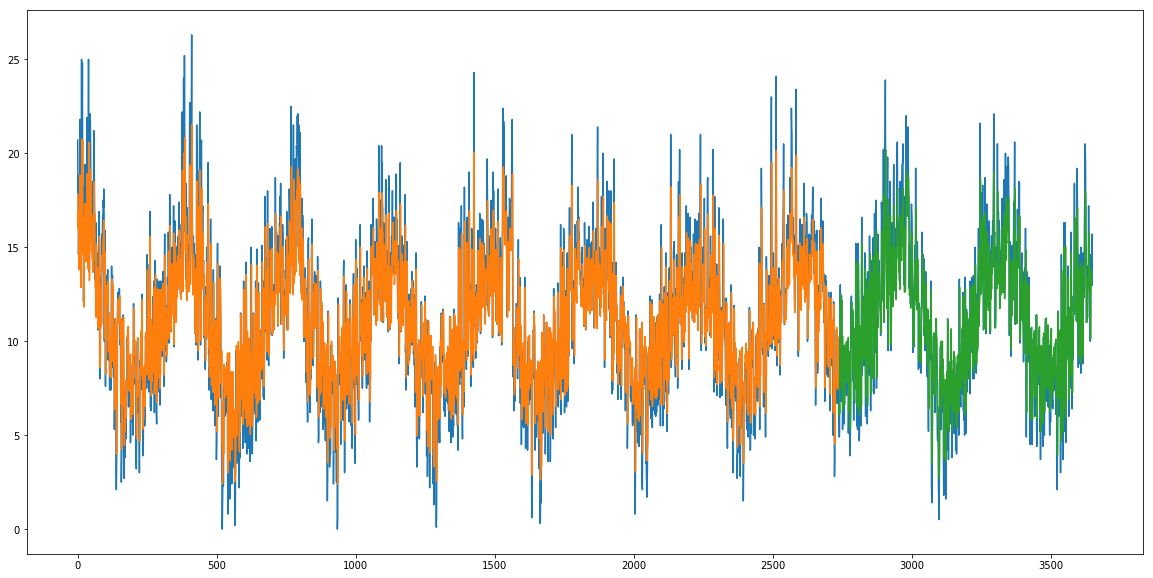

In [36]:
trainPredictPlot = np.empty_like(scaled)
trainPredictPlot[:, :] = np.nan
trainPredictPlot[look_back:len(trainPredict)+look_back, :] = trainPredict
# shift test predictions for plotting
testPredictPlot = np.empty_like(scaled)
testPredictPlot[:, :] = np.nan
testPredictPlot[len(trainPredict)+(look_back*2)+1:len(scaled)-1, :] = testPredict
plt.figure(figsize=(20,10))
plt.plot(scaler.inverse_transform(scaled))
plt.plot(trainPredictPlot)
plt.plot(testPredictPlot)
plt.show()